In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

In [2]:
FONT_FAMILY = "DejaVu Sans"   
BASE_FONT_SIZE = 10           

mpl.rcParams.update({
    'font.family': FONT_FAMILY,
    'font.size': BASE_FONT_SIZE,            
    'axes.titlesize': BASE_FONT_SIZE + 2,   
    'axes.labelsize': BASE_FONT_SIZE + 0,   
    'xtick.labelsize': BASE_FONT_SIZE - 1,  
    'ytick.labelsize': BASE_FONT_SIZE - 1,  
    'legend.fontsize': BASE_FONT_SIZE - 1,  
    'legend.title_fontsize': BASE_FONT_SIZE,
    'figure.titlesize': BASE_FONT_SIZE + 2, 
    'axes.linewidth': 0.8,                  
    'legend.frameon': False,
    'legend.handlelength': 1.2,
    'legend.handleheight': 0.8,
    'savefig.dpi': 300,                     
    'pdf.fonttype': 42,   
    'ps.fonttype': 42,
    'svg.fonttype': 'none'  
})

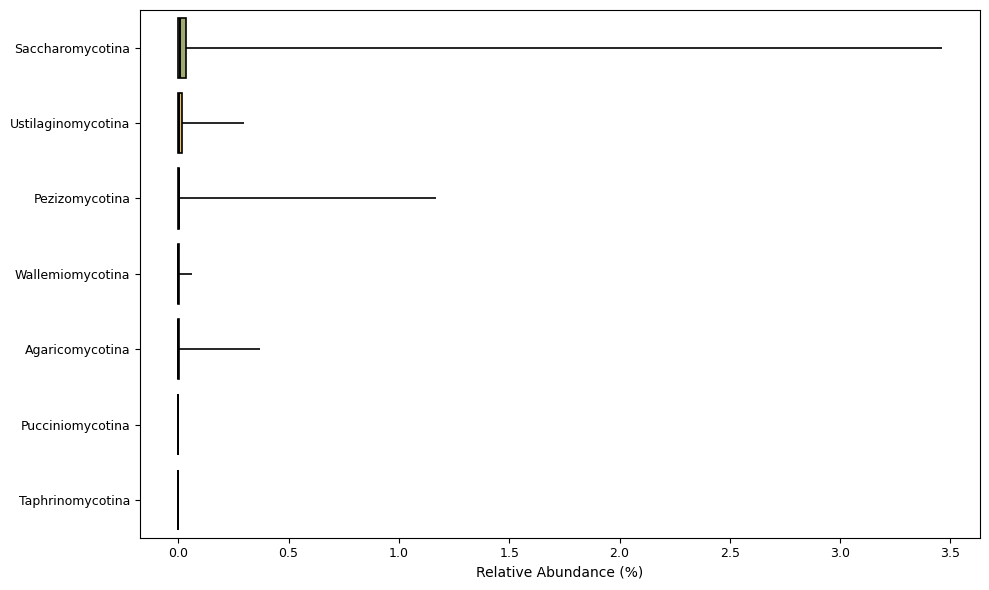

                  sample_name           subphylum  relative_abundance  \
0      13114.angenent.65.s009    Saccharomycotina            0.164060   
1    13114.bittleston.68.s010    Pucciniomycotina            0.000517   
2    13114.bittleston.68.s010    Saccharomycotina            0.006302   
3         13114.bowen.74.s013    Wallemiomycotina            0.005188   
4        13114.jensen.43.s003  Ustilaginomycotina            0.029107   
..                        ...                 ...                 ...   
831        13114.song.75.s002    Saccharomycotina            0.045422   
832        13114.song.75.s003      Pezizomycotina            0.006786   
833        13114.song.75.s003    Saccharomycotina            0.037838   
834        13114.song.75.s004      Pezizomycotina            0.004786   
835        13114.song.75.s004    Saccharomycotina            0.028799   

        subphylum_label  
0      Saccharomycotina  
1      Pucciniomycotina  
2      Saccharomycotina  
3      Wallemiomyco

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

final_df = pd.read_csv("kraken_absolute_isyeast_final.tsv", sep="\t")
reads_df = pd.read_csv("reads_earth_microbiomes_k2_B.tsv", sep="\t")
eukdetect_df = pd.read_csv("earth_microbiomes_eukdetect_subphylum.tsv", sep="\t")


empo_map = (
    eukdetect_df
    .dropna(subset=['sample_name', 'empo_3'])
    .groupby('sample_name')['empo_3']
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
)
reads_df['empo_3'] = reads_df['sample_name'].map(empo_map)


exclude_cols = ['taxid', 'kingdom', 'phylum', 'class', 'order', 'family',
                'genus', 'species', 'subphylum', 'isyeast']
sample_cols = [c for c in final_df.columns if c not in exclude_cols]


yeast_mask = final_df[final_df['isyeast'] == 'Y'][sample_cols].sum() > 0
samples_with_yeast = yeast_mask[yeast_mask].index.tolist()



records = []

for col in samples_with_yeast:
    total_reads = reads_df.loc[reads_df['sample_name'] == col, 'total'].values[0]

    tmp = final_df[['subphylum', col, 'isyeast']].dropna(subset=['subphylum'])
    tmp = tmp[tmp[col] > 0]
    tmp = tmp[tmp['isyeast'] == 'Y']

    if tmp.empty:
        continue

    sub_sums = tmp.groupby('subphylum')[col].sum()
    
    for subphylum, count in sub_sums.items():
        rel_abundance = (count / total_reads) * 100 if total_reads > 0 else 0
        records.append({
            'sample_name': col,
            'subphylum': subphylum,
            'relative_abundance': rel_abundance
        })

box_df = pd.DataFrame(records)
box_df['subphylum_label'] = box_df['subphylum'].fillna('None')


q3_values = box_df.groupby('subphylum_label')['relative_abundance'].quantile(0.75)
order = q3_values.sort_values(ascending=False).index

custom_colors = {
    'Saccharomycotina': "#A4B465",
    'Pucciniomycotina': "#FFEEAD",
    'Agaricomycotina': "#626F47",
    'Ustilaginomycotina': "#FFCF50",
    'Pezizomycotina': "#ECB390",
    'Taphrinomycotina': "#914F1E",
    'Entomophthoromycotina': "#D5CEA3",
    'Glomeromycotina': "#C2B280",
    'Mortierellomycotina': "#B7A57A",
    'Mucoromycotina': "#A67B5B",
    'Wallemiomycotina': "#8E806A",
    'Zoopagomycotina': "#C0A080",
    'Kickxellomycotina': "#B08B4F",
    'None': "#D3D3D3"
}
palette = {k: v for k, v in custom_colors.items() if k in box_df['subphylum_label'].unique()}

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=box_df,
    y='subphylum_label',
    x='relative_abundance',
    order=order,            
    orient='h',
    showmeans=False,
    showfliers=False,
    hue='subphylum_label',
    palette=palette,
    dodge=False,
    linewidth=1.2,
    whis=[0, 100],                     
    boxprops=dict(edgecolor='black', linewidth=1.2),
    whiskerprops=dict(linewidth=1.2, color='black'),
    capprops=dict(linewidth=0),
    medianprops=dict(linewidth=1.4, color='black')
)

ax.set_ylabel('')
plt.xlabel("Relative Abundance (%)")
plt.tight_layout()
plt.show()

print(box_df)
#box_df.to_csv("Figure7_1.tsv", sep='\t', index=False)

Sample totali nel file counts: 817
Sample presenti nel metadata e trovati nel file counts: 817


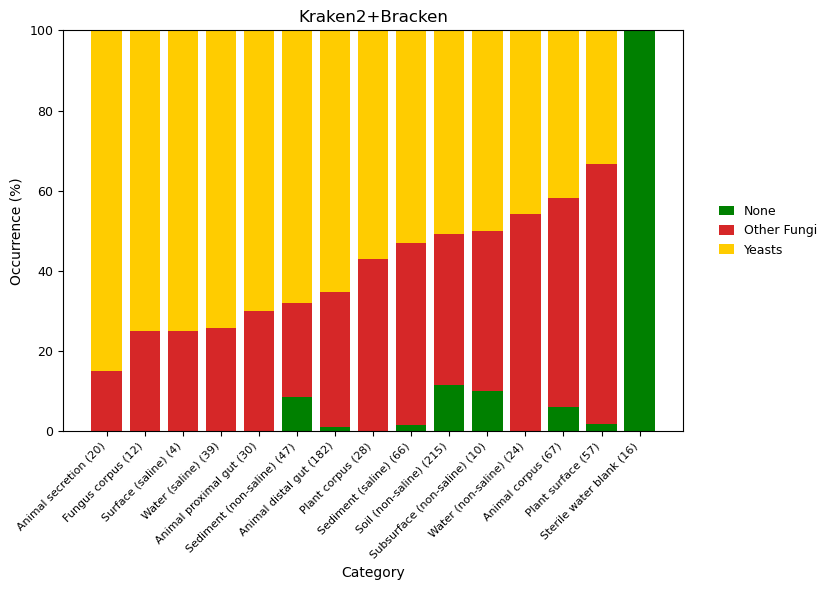

                               None  Other Fungi      Yeast  n_samples  \
Animal secretion           0.000000    15.000000  85.000000         20   
Fungus corpus              0.000000    25.000000  75.000000         12   
Surface (saline)           0.000000    25.000000  75.000000          4   
Water (saline)             0.000000    25.641026  74.358974         39   
Animal proximal gut        0.000000    30.000000  70.000000         30   
Sediment (non-saline)      8.510638    23.404255  68.085106         47   
Animal distal gut          1.098901    33.516484  65.384615        182   
Plant corpus               0.000000    42.857143  57.142857         28   
Sediment (saline)          1.515152    45.454545  53.030303         66   
Soil (non-saline)         11.627907    37.674419  50.697674        215   
Subsurface (non-saline)   10.000000    40.000000  50.000000         10   
Water (non-saline)         0.000000    54.166667  45.833333         24   
Animal corpus              5.970149   

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t')

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

meta_file = "earth_microbiomes_eukdetect_subphylum.tsv"
df_meta = pd.read_csv(meta_file, sep='\t')

df_meta_unique = df_meta[['sample_name','empo_3']].drop_duplicates()

df_meta_unique = df_meta_unique[df_meta_unique['sample_name'].isin(sample_cols)]

print(f"Sample totali nel file counts: {len(sample_cols)}")
print(f"Sample presenti nel metadata e trovati nel file counts: {len(df_meta_unique)}")

sample_to_category = dict(zip(df_meta_unique['sample_name'], df_meta_unique['empo_3']))

sample_subcategory = {}

isyeast_vals = df_counts['isyeast'] if 'isyeast' in df_counts.columns else pd.Series(['N']*len(df_counts))

for sample in sample_cols:
    if (isyeast_vals == 'Y').any():  
        has_yeast = df_counts.loc[isyeast_vals == 'Y', sample].gt(0).any()
        if has_yeast:
            sample_subcategory[sample] = 'Yeast'
            continue
    
    if df_counts[sample].sum() == 0:
        sample_subcategory[sample] = 'None'
    else:
        sample_subcategory[sample] = 'Other Fungi'

categories = sorted(set(sample_to_category.values()))
subcategories = ['None', 'Other Fungi', 'Yeast'] 

data = {sub: [] for sub in subcategories}
n_samples_per_cat = {}

for cat in categories:
    samples_in_cat = [s for s, c in sample_to_category.items() if c == cat and s in sample_subcategory]
    n_total = len(samples_in_cat)
    n_samples_per_cat[cat] = n_total

    counts = {sub: 0 for sub in subcategories}
    for s in samples_in_cat:
        counts[sample_subcategory[s]] += 1
    
    for sub in subcategories:
        data[sub].append((counts[sub] / n_total * 100) if n_total > 0 else 0)

df_plot = pd.DataFrame(data, index=categories)

df_plot['n_samples'] = df_plot.index.map(n_samples_per_cat)
df_plot['label'] = [f"{cat} ({n_samples_per_cat[cat]})" for cat in df_plot.index]
df_plot = df_plot.sort_values(by='Yeast', ascending=False)

colors = {
    "None": "green",
    "Other Fungi": "#d62728",  
    "Yeast": "#ffcc00"         
}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_plot))
labels = df_plot['label']

none_vals = df_plot['None']
other_vals = df_plot['Other Fungi']
yeast_vals = df_plot['Yeast']

ax.bar(x, none_vals, color=colors["None"], label="None", width=0.8)
ax.bar(x, other_vals, bottom=none_vals, color=colors["Other Fungi"], label="Other Fungi", width=0.8)
ax.bar(x, yeast_vals, bottom=none_vals + other_vals, color=colors["Yeast"], label="Yeasts", width=0.8)

ax.set_xticks(x)
ax.set_title("Kraken2+Bracken", fontsize=12)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Occurrence (%)", fontsize=10)
ax.set_xlabel("Category", fontsize=10)
ax.grid(False)


ax.legend(
    bbox_to_anchor=(1.05, 0.5),
    loc="center left",
    borderaxespad=0.0,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


print(df_plot)
#df_plot.to_csv("Figure5_a1.tsv", sep='\t')

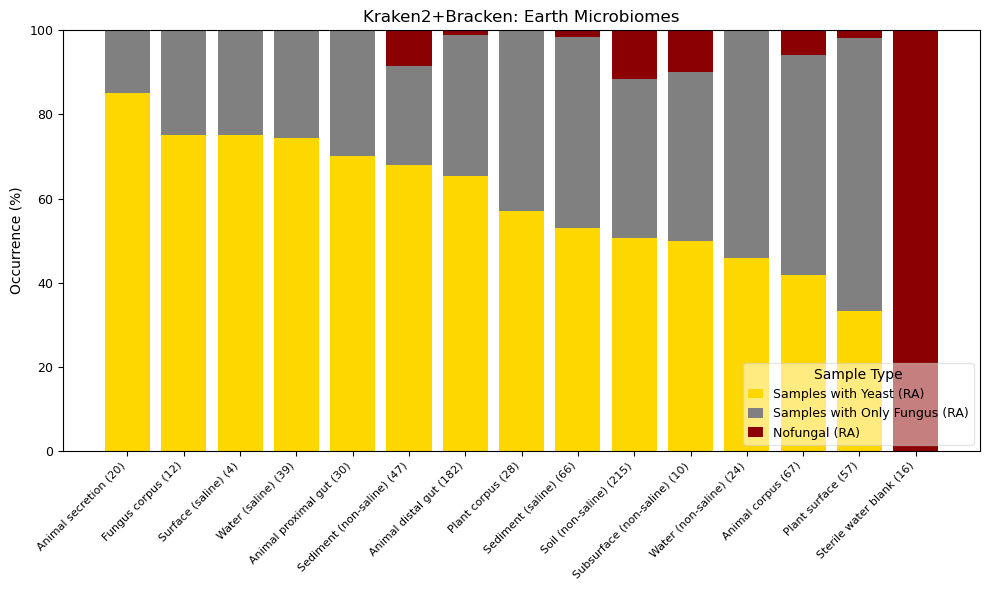

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

counts_file = "kraken_absolute_isyeast_final.tsv"
meta_file = "earth_microbiomes_eukdetect_subphylum.tsv"

df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

for col in sample_cols:
    df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)

df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)

df_meta = df_meta[['sample_name', 'empo_3']].dropna(subset=['empo_3'])
df_meta_unique = df_meta.drop_duplicates()

df_meta_unique = df_meta_unique[df_meta_unique['sample_name'].isin(sample_cols)]


sample_to_category = dict(zip(df_meta_unique['sample_name'], df_meta_unique['empo_3']))


sample_subcategory = {}
isyeast_vals = df_counts['isyeast'] if 'isyeast' in df_counts.columns else pd.Series(['N']*len(df_counts))

for sample in sample_cols:
    if sample not in sample_to_category:
        continue
        
    reads = df_counts[sample]

    has_yeast = ((isyeast_vals == 'Y') & (reads > 0)).any()
    has_other_fungi = ((isyeast_vals == 'N') & (reads > 0)).any()

    if has_yeast:
        sample_subcategory[sample] = 'Yeast'
    elif has_other_fungi:
        sample_subcategory[sample] = 'Other Fungi'
    else:
        sample_subcategory[sample] = 'None'

categories = sorted(set(sample_to_category.values()))
subcategories = ['None', 'Other Fungi', 'Yeast']

data = {sub: [] for sub in subcategories}
n_samples_per_cat = {}

for cat in categories:
    samples_in_cat = [s for s, c in sample_to_category.items() if c == cat and s in sample_subcategory]
    n_total = len(samples_in_cat)
    n_samples_per_cat[cat] = n_total

    counts = {sub: 0 for sub in subcategories}
    for s in samples_in_cat:
        counts[sample_subcategory[s]] += 1

    for sub in subcategories:
        data[sub].append((counts[sub] / n_total * 100) if n_total > 0 else 0)

df_plot = pd.DataFrame(data, index=categories)
df_plot['n_samples'] = df_plot.index.map(n_samples_per_cat)
df_plot['label'] = [f"{cat} ({n_samples_per_cat[cat]})" for cat in df_plot.index]
df_plot = df_plot.sort_values(by='Yeast', ascending=False)

df_plot = df_plot.rename(columns={
    "Yeast": "Samples with Yeast (RA)",
    "Other Fungi": "Samples with Only Fungus (RA)",
    "None": "Nofungal (RA)"
})

category_order = df_plot['label'].tolist()
df_plot = df_plot.set_index('label').reindex(category_order)

columns_to_plot = ['Samples with Yeast (RA)',
                   'Samples with Only Fungus (RA)',
                   'Nofungal (RA)']

colors = ['gold', 'gray', 'darkred']

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(df_plot))

for col, color in zip(columns_to_plot, colors):
    values = df_plot[col].values
    ax.bar(df_plot.index, values, bottom=bottom, color=color, width=0.8, label=col)
    bottom += values

ax.set_title("Kraken2+Bracken: Earth Microbiomes", fontsize=12)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Occurrence (%)", fontsize=10) 
ax.set_xlabel("")  
ax.grid(False, axis='y')

ax.legend(
    title='Sample Type',
    loc='lower right',
    frameon=True,
    facecolor='white',
    framealpha=0.5,
    title_fontsize=10,
    fontsize=9
)

plt.tight_layout()
plt.show()
#df_plot.to_csv("Figure12_b.tsv", sep='\t')

Numero di sample unici nel metadata: 817
Absent: Q1 = 1.92e+06, Median = 5.90e+06, Q3 = 1.54e+07
Present: Q1 = 8.24e+06, Median = 1.72e+07, Q3 = 2.33e+07


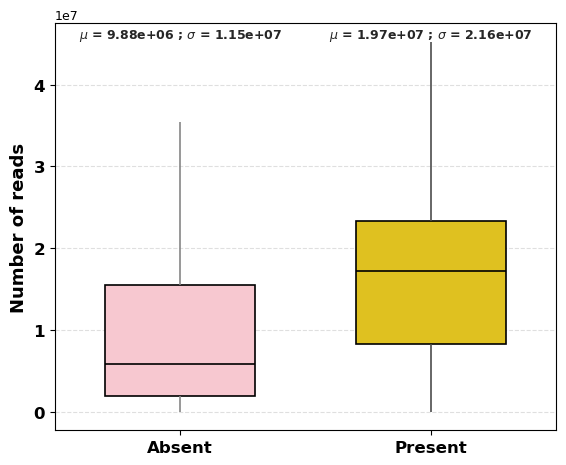

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

meta_file = "earth_microbiomes_eukdetect_subphylum.tsv"
df_meta = pd.read_csv(meta_file, sep='\t')

df_meta_unique = df_meta[['sample_name', 'reads_length']].drop_duplicates(subset='sample_name')
sample_to_reads = dict(zip(df_meta_unique['sample_name'], df_meta_unique['reads_length']))
print(f"Numero di sample unici nel metadata: {len(sample_to_reads)}")

counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t')

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]
valid_samples = [s for s in sample_cols if s in sample_to_reads]

isyeast_vals = df_counts['isyeast']
sample_status = {}
for sample in valid_samples:
    has_yeast = df_counts.loc[isyeast_vals == 'Y', sample].gt(0).any()
    sample_status[sample] = 'Present' if has_yeast else 'Absent'

data = pd.DataFrame({
    'sample_name': valid_samples,
    'reads_length': [sample_to_reads[s] for s in valid_samples],
    'status': [sample_status[s] for s in valid_samples]
})

absent_samples = data.loc[data['status'] == 'Absent', 'sample_name']
fungal_samples = []
non_fungal_samples = []

for sample in absent_samples:
    fungi_present = df_counts.loc[(df_counts['isyeast'] == 'N') & (df_counts[sample] > 0)]
    if not fungi_present.empty:
        fungal_samples.append(sample)
    else:
        non_fungal_samples.append(sample)

data_filtered = data.copy()
data_filtered = data_filtered[
    (data_filtered['status'] == 'Present') |
    (data_filtered['sample_name'].isin(fungal_samples))
]

order = ['Absent', 'Present']
palette = {'Absent': 'pink', 'Present': 'gold'}

fig, ax = plt.subplots(figsize=(6, 5), sharey=True)
sns.set(style="whitegrid", context="talk")

for i, status in enumerate(order):
    sns.boxplot(
        data=data_filtered[data_filtered['status'] == status],
        x='status',
        y='reads_length',
        color=palette[status],
        width=0.6,
        linewidth=1.5,
        showfliers=False,
        showcaps=False,
        medianprops={'color': 'black', 'linewidth': 1.2},
        boxprops={'edgecolor': 'black', 'linewidth': 1.2},
        whiskerprops={'linewidth': 1.2},
        ax=ax
    )

ax.set_xlabel("")
ax.set_ylabel("Number of reads", fontsize=13, fontweight="bold", fontname="DejaVu Sans")
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("DejaVu Sans")
    label.set_fontsize(12)
    label.set_fontweight("bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

stats = data_filtered.groupby('status')['reads_length'].agg(['mean', 'std'])
quartiles = data_filtered.groupby('status')['reads_length'].quantile([0.25, 0.5, 0.75]).unstack()

y_max = ax.get_ylim()[1]
y_pos = y_max * 0.95

for i, label in enumerate(order):
    if label in stats.index:
        mu = stats.loc[label, 'mean']
        sigma = stats.loc[label, 'std']
        q1 = quartiles.loc[label, 0.25]
        median = quartiles.loc[label, 0.5]
        q3 = quartiles.loc[label, 0.75]
        ax.text(
            i, y_pos,
            fr"$\mu$ = {mu:.2e} ; $\sigma$ = {sigma:.2e}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )
        print(f"{label}: Q1 = {q1:.2e}, Median = {median:.2e}, Q3 = {q3:.2e}")

plt.tight_layout()
plt.show()


fungal_lengths = [sample_to_reads[s] for s in fungal_samples if s in sample_to_reads]
nonfungal_lengths = [sample_to_reads[s] for s in non_fungal_samples if s in sample_to_reads]


#data_filtered.to_csv("Figure5_b1.tsv", sep='\t')

 - Non Yeast


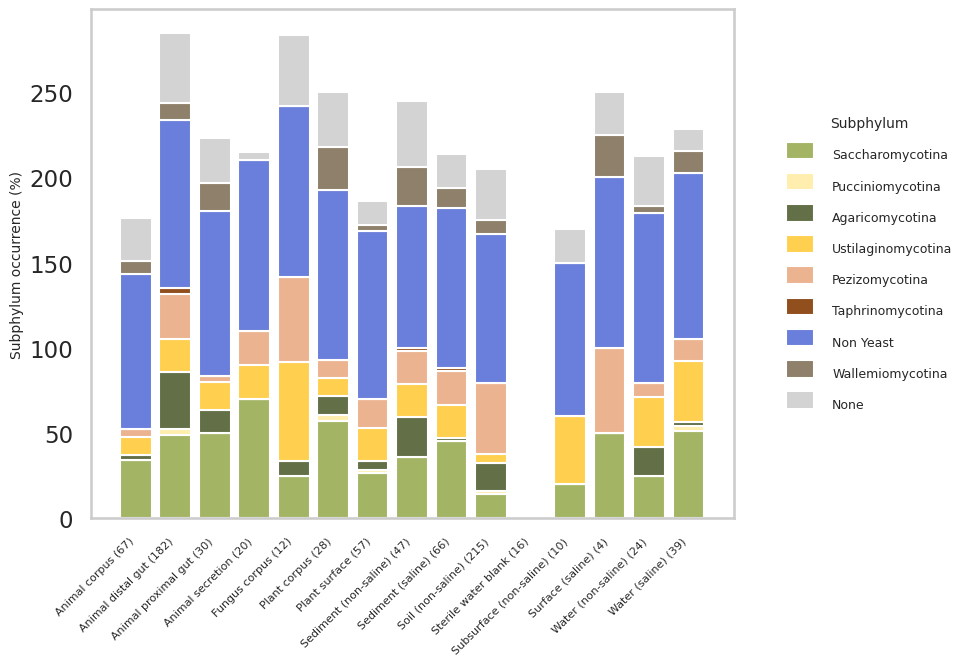

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from matplotlib.font_manager import FontProperties

counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t')

meta_file = "earth_microbiomes_eukdetect_subphylum.tsv"
df_meta = pd.read_csv(meta_file, sep='\t')

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [c for c in df_counts.columns if c not in ignore_cols]

df_meta_unique = df_meta[['sample_name','empo_3']].drop_duplicates()
df_meta_unique = df_meta_unique[df_meta_unique['sample_name'].isin(sample_cols)]

sample_to_category = dict(zip(df_meta_unique['sample_name'], df_meta_unique['empo_3']))

df_counts['subphylum'] = df_counts['subphylum'].fillna('').astype(str).str.strip()
df_counts['subphylum_norm'] = df_counts['subphylum'].replace('', 'None').str.capitalize()

mask_nonyeast = (df_counts['subphylum_norm'] != 'None') & (df_counts['isyeast'] == 'N')
df_counts.loc[mask_nonyeast, 'subphylum_norm'] = 'Non Yeast'

subphyla = sorted(df_counts['subphylum_norm'].unique())

categories = sorted(df_meta_unique['empo_3'].unique())
data = {sp: [] for sp in subphyla}
n_samples_per_cat = {}

for cat in categories:
    samples_in_cat = df_meta_unique.loc[df_meta_unique['empo_3'] == cat, 'sample_name']
    n_total = len(samples_in_cat)
    n_samples_per_cat[cat] = n_total

    for sp in subphyla:
        subset = df_counts[df_counts['subphylum_norm'] == sp]
        if subset.empty:
            frac = 0
        else:
            positive_samples = (subset[samples_in_cat] > 0).any(axis=0)
            n_positive = positive_samples.sum()
            frac = (n_positive / n_total * 100) if n_total > 0 else 0
        data[sp].append(frac)

df_plot = pd.DataFrame(data, index=categories)

custom_colors = {
    'Saccharomycotina': "#A4B465",
    'Pucciniomycotina': "#FFEEAD",
    'Agaricomycotina': "#626F47",
    'Ustilaginomycotina': "#FFCF50",
    'Pezizomycotina': "#ECB390",
    'Taphrinomycotina': "#914F1E",
    'Non Yeast': "#6A7FDB",
    'Wallemiomycotina': "#8E806A",
    'None': "#D3D3D3"
}

for sp in subphyla:
    if sp not in custom_colors:
        custom_colors[sp] = "#CCCCCC"

df_plot['n_samples'] = df_plot.index.map(n_samples_per_cat)
df_plot['label'] = [f"{cat} ({n_samples_per_cat[cat]})" for cat in df_plot.index]

only_nonyeast_subphyla = []
for sp in subphyla:
    subset = df_counts[df_counts['subphylum_norm'] == sp]
    if not subset.empty and all(subset['isyeast'] == 'N') and sp != 'None':
        only_nonyeast_subphyla.append(sp)

if only_nonyeast_subphyla:
    for sp in only_nonyeast_subphyla:
        print(f" - {sp}")
else:
    print("\n✅ No subphylum.")

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(df_plot))

subphyla_ordered = [sp for sp in custom_colors.keys() if sp in df_plot.columns]
bottom = np.zeros(len(df_plot))

for sp in subphyla_ordered:
    vals = df_plot[sp] if sp in df_plot.columns else np.zeros(len(df_plot))
    ax.bar(x, vals, bottom=bottom, label=sp, color=custom_colors[sp], width=0.8)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(df_plot['label'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Subphylum occurrence (%)", fontsize=10)
ax.grid(False)

handles, labels = ax.get_legend_handles_labels()
handles_filtered, labels_filtered = [], []

for h, l in zip(handles, labels):
    if l in custom_colors:
        handles_filtered.append(h)
        labels_filtered.append(l)

BASE_FONT_SIZE = 10
legend = ax.legend(
    handles_filtered,
    labels_filtered,
    bbox_to_anchor=(1.05, 0.5),
    loc="center left",
    frameon=False,
    title="Subphylum"
)
legend.set_title("Subphylum", prop=FontProperties(size=BASE_FONT_SIZE))
for text in legend.get_texts():
    text.set_fontsize(BASE_FONT_SIZE - 1)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

#df_plot.to_csv("Figure6_only_yeast_NON_NORMALIZED.tsv", sep='\t')



Fungi:
  μ (mean)     = 1.524e+00
  σ (std)       = 8.790e+00
  Median       = 6.23096e-02
  1° Quartile   = 2.630e-02
  3° Quartile   = 1.776e-01

Unclassified:
  μ (mean)     = 9.831e+01
  σ (std)       = 9.455e+00
  Median       = 9.99250e+01
  1° Quartile   = 9.976e+01
  3° Quartile   = 9.996e+01

Yeast:
  μ (mean)     = 2.467e-02
  σ (std)       = 1.524e-01
  Median       = 2.28672e-04
  1° Quartile   = 0.000e+00
  3° Quartile   = 7.243e-03


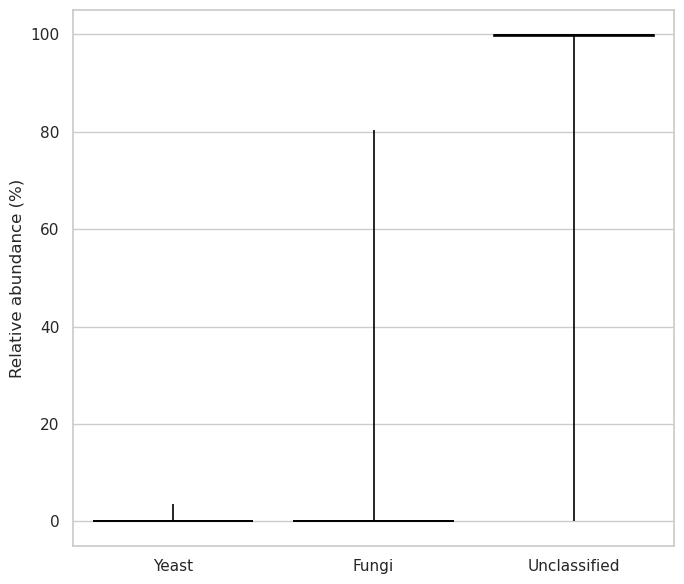

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

final_df = pd.read_csv("kraken_absolute_isyeast_final.tsv", sep="\t")
reads_df = pd.read_csv("reads_earth_microbiomes_k2_B.tsv", sep="\t")

exclude_cols = [
    'taxid', 'kingdom', 'phylum', 'class', 'order', 'family',
    'genus', 'species', 'subphylum', 'isyeast'
]
sample_cols = [col for col in final_df.columns if col not in exclude_cols]

results = []

for sample in sample_cols:
    row = reads_df[reads_df["sample_name"] == sample]
    if row.empty:
        continue

    total = float(row["total"].values[0])
    classified = float(row["classified"].values[0])
    unclassified = float(row["unclassified"].values[0])

    yeast_reads = final_df.loc[final_df["isyeast"] == "Y", sample].sum()
    nonyeast_reads = final_df.loc[final_df["isyeast"] == "N", sample].sum()

    perc_yeast = (yeast_reads / total) * 100 if total > 0 else 0
    perc_nonyeast = (nonyeast_reads / total) * 100 if total > 0 else 0
    perc_unclassified = (unclassified / total) * 100 if total > 0 else 0

    results.append({
        "sample": sample,
        "Yeast": perc_yeast,
        "Fungi": perc_nonyeast,
        "Unclassified": perc_unclassified
    })

df_perc = pd.DataFrame(results)

melted = df_perc.melt(
    id_vars="sample",
    value_vars=["Yeast", "Fungi", "Unclassified"],
    var_name="Category",
    value_name="Percentage"
)

summary_stats = melted.groupby("Category")["Percentage"].agg(
    mean="mean",
    std="std",
    median="median",
    q1=lambda x: np.percentile(x, 25),
    q3=lambda x: np.percentile(x, 75)
).reset_index()

for _, row in summary_stats.iterrows():
    print(f"\n{row['Category']}:")
    print(f"  μ (mean)     = {row['mean']:.3e}")
    print(f"  σ (std)       = {row['std']:.3e}")
    print(f"  Median       = {row['median']:.5e}")
    print(f"  1° Quartile   = {row['q1']:.3e}")
    print(f"  3° Quartile   = {row['q3']:.3e}")

sns.set(style="whitegrid")
palette = {"Yeast": "#FFD700", "Fungi": "#555555", "Unclassified": "#800020"}

plt.figure(figsize=(7, 6))
sns.boxplot(
    data=melted,
    x="Category", y="Percentage",
    palette=palette,
    hue="Category",
    showfliers=False,
    linewidth=1.2,
    whis=[0, 100],
    whiskerprops={'linestyle': '-', 'linewidth': 1.2, 'color': 'black'},
    capprops={'linewidth': 0},
    medianprops={'color': 'black', 'linewidth': 1.3},
    boxprops={'edgecolor': 'black'},
    legend=False
)

plt.ylabel("Relative abundance (%)", fontsize=12)
plt.xlabel("")
plt.tight_layout()
plt.show()

#df_perc.to_csv("Figure5_a1_and_a2.tsv", sep='\t')



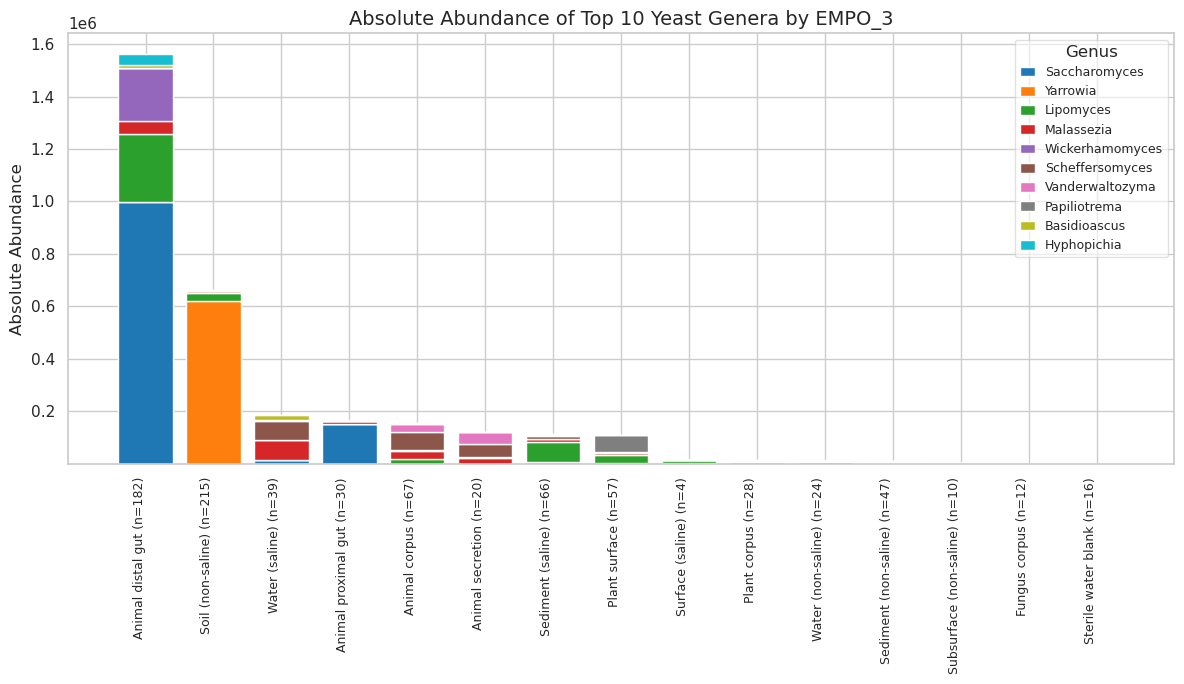

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter

counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

for col in sample_cols:
    df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)

meta_file = "earth_microbiomes_eukdetect_subphylum.tsv"
df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)

df_meta = df_meta[['sample_name', 'empo_3']].dropna(subset=['empo_3'])
df_meta_unique = df_meta.drop_duplicates()
df_meta_unique = df_meta_unique[df_meta_unique['sample_name'].isin(sample_cols)]

sample_to_category = dict(zip(df_meta_unique['sample_name'], df_meta_unique['empo_3']))

isyeast_mask = df_counts['isyeast'] == 'Y'
df_yeast = df_counts[isyeast_mask]

genus_sums = df_yeast.groupby("genus")[sample_cols].sum()

genus_total = genus_sums.sum(axis=1).sort_values(ascending=False)
top10_genus = genus_total.head(10).index.tolist()

categories = sorted(set(sample_to_category.values()))
category_abundance = {genus: {cat: 0 for cat in categories} for genus in top10_genus}
samples_per_category = {cat: 0 for cat in categories}

for sample, cat in sample_to_category.items():
    if sample not in genus_sums.columns:
        continue
    
    samples_per_category[cat] += 1
    
    for genus in top10_genus:
        reads = genus_sums.at[genus, sample]
        category_abundance[genus][cat] += reads

df_abundance = pd.DataFrame(category_abundance).fillna(0)

df_abundance['n_samples'] = [samples_per_category.get(cat, 0) for cat in df_abundance.index]

df_abundance['total_abundance'] = df_abundance[top10_genus].sum(axis=1)
df_abundance = df_abundance.sort_values(by='total_abundance', ascending=False)
df_abundance = df_abundance.drop(columns='total_abundance')

plt.figure(figsize=(12, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(top10_genus)))
genus_color_map = dict(zip(top10_genus, colors))

bottom = np.zeros(len(df_abundance))

for genus in top10_genus:
    vals = df_abundance[genus].values
    plt.bar(df_abundance.index, vals, bottom=bottom, label=genus,
            color=genus_color_map[genus])
    bottom += vals

labels = [f"{cat} (n={df_abundance.loc[cat,'n_samples']})" for cat in df_abundance.index]

plt.title("Absolute Abundance of Top 10 Yeast Genera by EMPO_3", fontsize=14)
plt.ylabel("Absolute Abundance", fontsize=12)
plt.xlabel("")
plt.xticks(range(len(df_abundance.index)), labels, rotation=90, ha='right', fontsize=9)

plt.legend(
    title="Genus",
    loc="upper right",
    frameon=True,
    facecolor='white',
    framealpha=0.6,
    fontsize=9
)

plt.tight_layout()
#plt.savefig("plots/absolute_ab_sample_earth_K2_B.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

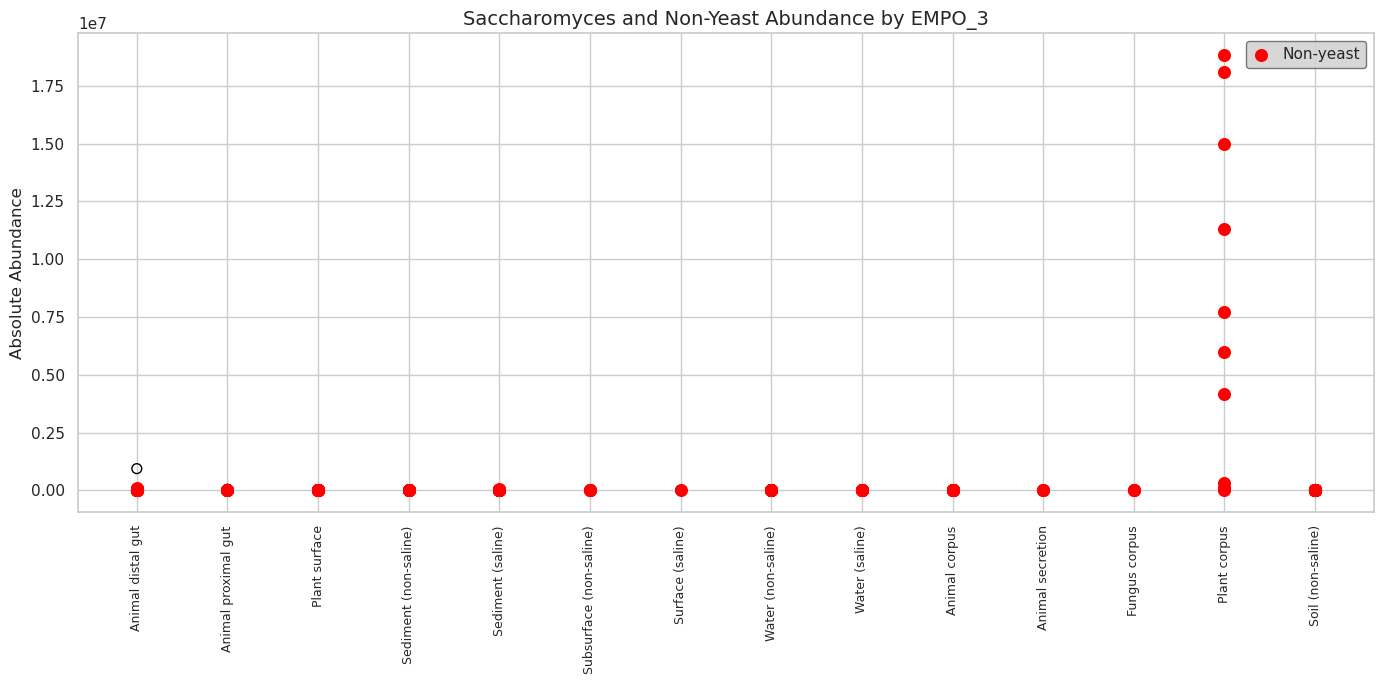

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

counts_file = "kraken_absolute_isyeast_final.tsv"
df_counts = pd.read_csv(counts_file, sep='\t', low_memory=False, dtype=str)

ignore_cols = ['taxid','kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
sample_cols = [col for col in df_counts.columns if col not in ignore_cols]

for col in sample_cols:
    df_counts[col] = pd.to_numeric(df_counts[col], errors='coerce').fillna(0)

meta_file = "earth_microbiomes_eukdetect_subphylum.tsv"
df_meta = pd.read_csv(meta_file, sep='\t', low_memory=False, dtype=str)

cols_to_keep = ['sample_name', 'empo_1', 'empo_2', 'empo_3', 'empo_4']
if 'empo_3' in df_meta.columns:
    df_meta = df_meta.dropna(subset=["empo_3"])
df_meta_unique = df_meta.drop_duplicates(subset=['sample_name'])


sample_metadata = {}
for _, row in df_meta_unique.iterrows():
    sample_name = row.get('sample_name')
    if pd.notna(sample_name):
        sample_metadata[sample_name] = {
            'category': row.get('empo_3', 'other'),
            'empo_1': row.get('empo_1', ''),
            'empo_2': row.get('empo_2', ''),
            'empo_3': row.get('empo_3', ''),
            'empo_4': row.get('empo_4', '')
        }

genus_col = df_counts['genus'].fillna('')
df_saccharomyces = df_counts[genus_col.str.lower() == 'saccharomyces'].copy()

isyeast_col = df_counts['isyeast'].fillna('')
df_yeast = df_counts[isyeast_col == 'Y'].copy()       
df_non_yeast = df_counts[isyeast_col == 'N'].copy()   

saccharo_rows = []

for sample in sample_cols:
    if sample not in sample_metadata:
        continue
    
    if sample in df_saccharomyces.columns:
        abundance = df_saccharomyces[sample].sum()
        if abundance > 0:
            row_data = {'sample': sample, 'abundance': abundance}
            row_data.update(sample_metadata[sample])  
            saccharo_rows.append(row_data)

scatter_saccharo_df = pd.DataFrame(saccharo_rows)

non_yeast_samples = []

for sample in sample_cols:
    if sample not in sample_metadata:
        continue
    
    sample_yeast_abundance = df_yeast[sample].sum() if sample in df_yeast.columns else 0
    if sample_yeast_abundance == 0:
        abundance = df_non_yeast[sample].sum() if sample in df_non_yeast.columns else 0
        if abundance > 0:
            row_data = {'sample': sample, 'abundance': abundance}
            row_data.update(sample_metadata[sample])
            non_yeast_samples.append(row_data)

scatter_non_yeast_df = pd.DataFrame(non_yeast_samples)

category_order = sorted(set([meta['category'] for meta in sample_metadata.values() if pd.notna(meta['category'])]))

if not scatter_saccharo_df.empty:
    scatter_saccharo_df['category'] = pd.Categorical(scatter_saccharo_df['category'], categories=category_order, ordered=True)
if not scatter_non_yeast_df.empty:
    scatter_non_yeast_df['category'] = pd.Categorical(scatter_non_yeast_df['category'], categories=category_order, ordered=True)

plt.figure(figsize=(14,7))

if not scatter_saccharo_df.empty:
    for cat in category_order:
        df_cat = scatter_saccharo_df[scatter_saccharo_df['category'] == cat]
        if not df_cat.empty:
            plt.scatter([cat]*len(df_cat), df_cat['abundance'], facecolors='none', edgecolors='black', s=50, label='Saccharomyces' if cat == category_order[0] else "")

if not scatter_non_yeast_df.empty:
    for cat in category_order:
        df_cat = scatter_non_yeast_df[scatter_non_yeast_df['category'] == cat]
        if not df_cat.empty:
            plt.scatter([cat]*len(df_cat), df_cat['abundance'], color='red', s=70, label='Non-yeast' if cat == category_order[0] else "")

plt.xticks(rotation=90, fontsize=9)
plt.ylabel("Absolute Abundance", fontsize=12)
plt.xlabel("")
plt.title("Saccharomyces and Non-Yeast Abundance by EMPO_3", fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
if by_label:
    plt.legend(by_label.values(), by_label.keys(), loc='upper right', facecolor='lightgray', edgecolor='dimgray', framealpha=0.9, frameon=True)

plt.tight_layout()
plt.show()

taxonomy_cols = ['kingdom','phylum','subphylum','class','order','family','genus','species']

def get_taxonomy_for_sample(df_from_taxa, sample_name, df_counts_full, taxonomy_cols):
    if sample_name not in df_from_taxa.columns:
        return {c: None for c in taxonomy_cols}
    try:
        idx_max = df_from_taxa[sample_name].astype(float).idxmax()
    except Exception:
        return {c: None for c in taxonomy_cols}
    
    df_counts_unique = df_counts_full.loc[:, ~df_counts_full.columns.duplicated()]
    if idx_max in df_counts_unique.index:
        row = df_counts_unique.loc[idx_max]
    else:
        return {c: None for c in taxonomy_cols}
        
    out = {}
    for c in taxonomy_cols:
        out[c] = row[c] if c in row.index else None
    return out

if not scatter_saccharo_df.empty:
    top3_saccharo = []
    for cat in category_order:
        df_cat = scatter_saccharo_df[scatter_saccharo_df['category'] == cat]
        if not df_cat.empty:
            top3_saccharo.append(df_cat.nlargest(3, 'abundance'))
    
    if top3_saccharo:
        top3_saccharo_df = pd.concat(top3_saccharo, axis=0).reset_index(drop=True)
        tax_rows = [get_taxonomy_for_sample(df_saccharomyces, row['sample'], df_counts, taxonomy_cols) for _, row in top3_saccharo_df.iterrows()]
        top3_saccharo_final = pd.concat([pd.DataFrame(tax_rows), top3_saccharo_df], axis=1)
        #top3_saccharo_final.to_csv("top3_saccharomyces_earth.tsv", sep='\t', index=False)
    
    #scatter_saccharo_df.to_csv("Figure12_d_black_dots.tsv", sep='\t', index=False)

if not scatter_non_yeast_df.empty:
    top3_non_yeast = []
    for cat in category_order:
        df_cat = scatter_non_yeast_df[scatter_non_yeast_df['category'] == cat]
        if not df_cat.empty:
            top3_non_yeast.append(df_cat.nlargest(3, 'abundance'))
    
    if top3_non_yeast:
        top3_non_yeast_df = pd.concat(top3_non_yeast, axis=0).reset_index(drop=True)
        tax_rows = [get_taxonomy_for_sample(df_non_yeast, row['sample'], df_counts, taxonomy_cols) for _, row in top3_non_yeast_df.iterrows()]
        top3_non_yeast_final = pd.concat([pd.DataFrame(tax_rows), top3_non_yeast_df], axis=1)
        #top3_non_yeast_final.to_csv("top3_non_yeast_earth.tsv", sep='\t', index=False)

    #scatter_non_yeast_df.to_csv("Figure12_d_red_dots.tsv", sep='\t', index=False)

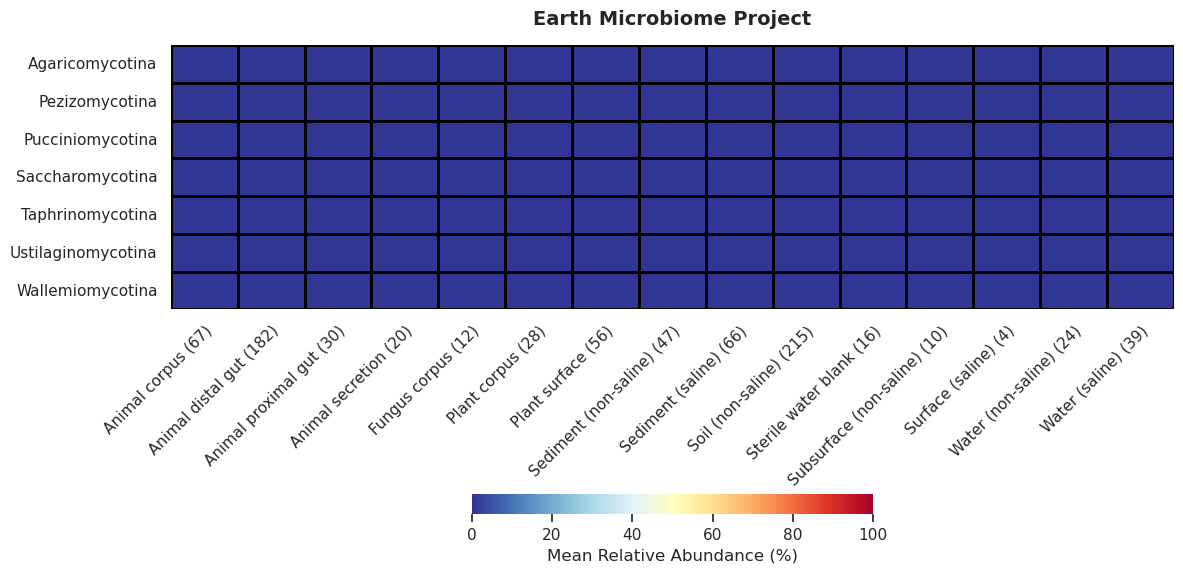

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

final_df = pd.read_csv("kraken_absolute_isyeast_final.tsv", sep="\t")
reads_df = pd.read_csv("reads_earth_microbiomes_k2_B.tsv", sep="\t")
eukdetect_df = pd.read_csv("earth_microbiomes_eukdetect_subphylum.tsv", sep="\t")

empo_map = (
    eukdetect_df.dropna(subset=['sample_name', 'empo_3'])
    .groupby('sample_name')['empo_3']
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

reads_dict = reads_df.set_index('sample_name')['total'].to_dict()

valid_samples = [s for s in final_df.columns if s in empo_map and s in reads_dict and reads_dict[s] > 0]

yeast_df = final_df[final_df['isyeast'] == 'Y'].copy()
yeast_grouped = yeast_df.groupby('subphylum')[valid_samples].sum()

rel_abund_df = yeast_grouped.copy()
for sample in valid_samples:
    rel_abund_df[sample] = (rel_abund_df[sample] / reads_dict[sample]) * 100

df_melted = rel_abund_df.T.reset_index()
df_melted.rename(columns={'index': 'sample_name'}, inplace=True)

df_melted['empo_3'] = df_melted['sample_name'].map(empo_map)

mean_abund = df_melted.groupby('empo_3').mean(numeric_only=True).T

sample_counts = df_melted['empo_3'].value_counts().to_dict()

mean_abund.columns = [f"{col} ({sample_counts[col]})" for col in mean_abund.columns]

mean_abund = mean_abund.sort_index()

plt.figure(figsize=(12, 6))

ax = sns.heatmap(
    mean_abund,
    vmin=0,
    vmax=100,
    cmap="RdYlBu_r",         
    linewidths=1,
    linecolor='black',
    cbar_kws={'label': 'Mean Relative Abundance (%)', 'orientation': 'horizontal', 'shrink': 0.4, 'pad': 0.35}
)

plt.title("Earth Microbiome Project", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("")
plt.ylabel("")

plt.xticks(rotation=45, ha='right', rotation_mode="anchor")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#mean_abund.to_csv("Heatmap_EMP_data_mean_relative_abundances.tsv", sep='\t')

In [15]:
import pandas as pd

HOME = "." 

its_df = pd.read_csv(f'07_ITS_SamplesMinReads1000GenusMinPerc0.05.tsv', sep='\t', index_col=0)
euk_df = pd.read_csv(f'07_occurrence_eukdetect_earth_microbiomes_1000filtered.tsv', sep='\t', index_col=0)
kraken_df = pd.read_csv(f'07_Kraken_1000ReadsITS_grouped_counts.tsv', sep='\t', index_col=0)

its_df = its_df.rename(columns={'Yeast Count': 'Yeast', 'Total Samples': 'Total_Samples'})
euk_df = euk_df.rename(columns={'Yeast Count': 'Yeast', 'Total Samples': 'Total_Samples'})
kraken_df = kraken_df.rename(columns={'Samples with Yeast': 'Yeast', 'Total Samples': 'Total_Samples'})

common_rows = its_df.index.intersection(euk_df.index).intersection(kraken_df.index).tolist()

rows = []
for empo_3 in common_rows:
    
    its_tot = its_df.loc[empo_3, 'Total_Samples']
    its_yeast = its_df.loc[empo_3, 'Yeast']
    its_perc = (its_yeast / its_tot * 100) if its_tot > 0 else 0
    rows.append({'category': empo_3, 'Source': 'ITS', 'Yeast Percentage': its_perc, 'n_samples': its_tot})

    
    euk_tot = euk_df.loc[empo_3, 'Total_Samples']
    euk_yeast = euk_df.loc[empo_3, 'Yeast']
    euk_perc = (euk_yeast / euk_tot * 100) if euk_tot > 0 else 0
    rows.append({'category': empo_3, 'Source': 'Euk', 'Yeast Percentage': euk_perc, 'n_samples': euk_tot})

    
    kraken_tot = kraken_df.loc[empo_3, 'Total_Samples']
    kraken_yeast = kraken_df.loc[empo_3, 'Yeast']
    kraken_perc = (kraken_yeast / kraken_tot * 100) if kraken_tot > 0 else 0
    rows.append({'category': empo_3, 'Source': 'Kraken', 'Yeast Percentage': kraken_perc, 'n_samples': kraken_tot})

out_df = pd.DataFrame(rows)
#out_df.to_csv(figure9_EMP/Figure9_a.tsv", sep="\t", index=False)


In [16]:
import pandas as pd
import numpy as np

file_path = "kraken_absolute_isyeast_final.tsv"
df = pd.read_csv(file_path, sep='\t', low_memory=False, dtype=str)

ignore_cols = ['taxid', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'subphylum', 'isyeast']
sample_cols = [col for col in df.columns if col not in ignore_cols]
total_samples = len(sample_cols)

for col in sample_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['isyeast'] = df['isyeast'].str.strip().str.upper()

df_yeast = df[df['isyeast'] == 'Y']
df_non_yeast = df[df['isyeast'] == 'N']

yeast_sample_totals = df_yeast[sample_cols].sum(axis=0)
non_yeast_sample_totals = df_non_yeast[sample_cols].sum(axis=0)
all_fungi_sample_totals = df[sample_cols].sum(axis=0)


yeast_count = (yeast_sample_totals > 0).sum()
non_yeast_count = (non_yeast_sample_totals > 0).sum()
zero_fungi_count = (all_fungi_sample_totals == 0).sum()

perc_yeast = (yeast_count / total_samples) * 100
perc_non_yeast = (non_yeast_count / total_samples) * 100
perc_zero = (zero_fungi_count / total_samples) * 100


print("\n" + "="*50)
print("Results:")
print("="*50)
print(f"🔹 Samples with at least one yeast (Y):      {yeast_count} su {total_samples} ({perc_yeast:.2f}%)")
print(f"🔹 Samples with at least one non-yeast (N):  {non_yeast_count} su {total_samples} ({perc_non_yeast:.2f}%)")
print(f"🔹 Samples without fungi:   {zero_fungi_count} su {total_samples} ({perc_zero:.2f}%)")
print("="*50)

both_count = ((yeast_sample_totals > 0) & (non_yeast_sample_totals > 0)).sum()
perc_both = (both_count / total_samples) * 100
print(f"Samples with both yeast and non-yeast: {both_count} ({perc_both:.2f}%)")


Results:
🔹 Samples with at least one yeast (Y):      453 su 817 (55.45%)
🔹 Samples with at least one non-yeast (N):  753 su 817 (92.17%)
🔹 Samples without fungi:   54 su 817 (6.61%)
Samples with both yeast and non-yeast: 443 (54.22%)
